# Import the data annotation json

In [7]:
import json
with open("data/ml/machine-and-movement_complete.json", "r") as f:
    annotation_json = json.load(f)

In [8]:
import pandas as pd

# Convert nested dictionary to DataFrame
rows = []
for instance, events in annotation_json.items():
    for event in events:
        rows.append({
            'Instance': instance,
            'Label': event['label'],
            'Duration': event['duration'],
            'Start': event['start'],
            'End': event['end']
        })

df = pd.DataFrame(rows)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure numeric columns are numeric
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")
df["Start"] = pd.to_numeric(df["Start"], errors="coerce")
df["End"] = pd.to_numeric(df["End"], errors="coerce")

# Clean
df = df.dropna(subset=["Instance", "Label", "Duration", "Start", "End"])

# Optional: fixed order for labels
label_order = ["Clamping", "Bending", "Mandrel Extraction", "De-Clamping"]
df["Label"] = pd.Categorical(df["Label"], categories=label_order, ordered=True)
df = df.sort_values(["Label", "Instance"])

In [10]:
from pathlib import Path
dir = Path("results/activity_recognition/labelStatistic")

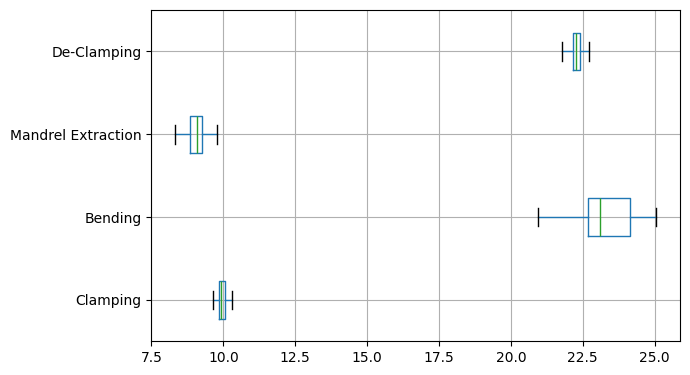

In [26]:
fig, ax = plt.subplots(figsize=(7,4))

df.boxplot(
    column="Duration",
    by="Label",
    ax=ax,
    vert=False,          # horizontal boxplot
    showfliers=False     # hide extreme outliers
)

ax.set_title("")
fig.suptitle("")
ax.set_ylabel("") 

plt.tight_layout()
plt.savefig(dir / "boxPlot.pdf")
plt.show()

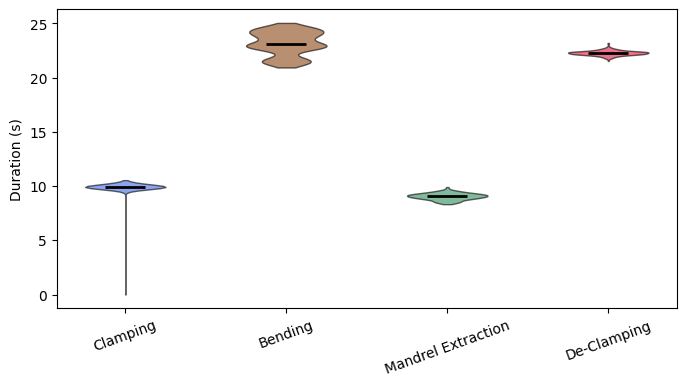

In [ ]:
import matplotlib.pyplot as plt

labels = ["Clamping", "Bending", "Mandrel Extraction", "De-Clamping"]

# Prepare grouped data
data = [df[df["Label"] == label]["Duration"] for label in labels]

# Same colors used before
colors = ["royalblue", "saddlebrown", "seagreen", "crimson"]

fig, ax = plt.subplots(figsize=(7,4))

# Violin plot
violins = ax.violinplot(
    data,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Color each violin
for body, color in zip(violins["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.6)

# Median line style
violins["cmedians"].set_color("black")
violins["cmedians"].set_linewidth(2)

ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels, rotation=20)

ax.set_ylabel("Duration (s)")

plt.tight_layout(pad=1.2)
plt.savefig(dir / "violon.pdf")
plt.show()

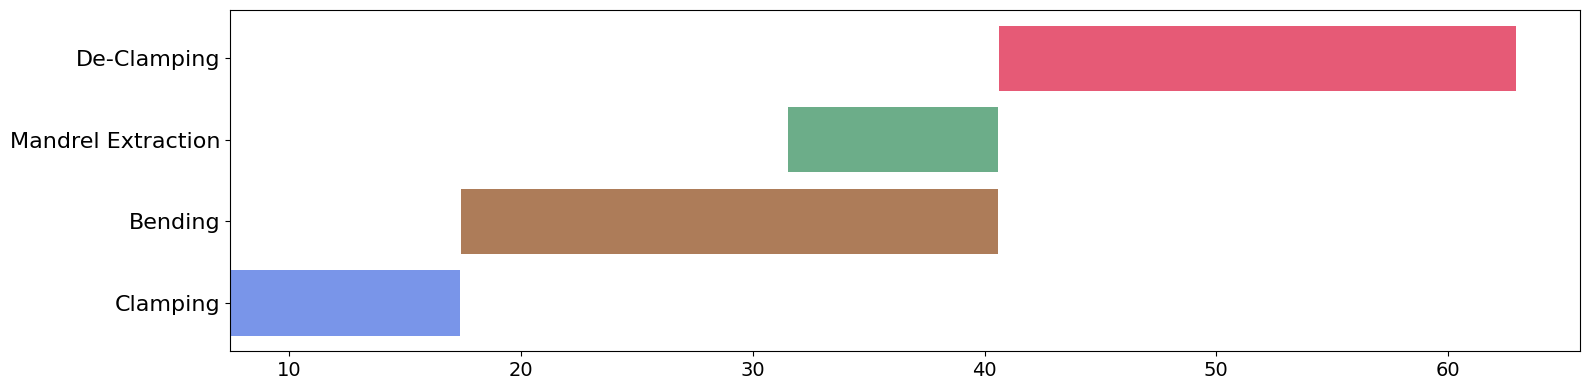

In [ ]:
range_stats = (
    df.groupby("Label", observed=True)
    .agg(
        mean_start=("Start", "mean"),
        mean_end=("End", "mean"),
        mean_duration=("Duration", "mean"),
    )
    .reindex(label_order)
)

fig, ax = plt.subplots(figsize=(16, 4))

y_positions = range(len(range_stats))

ax.barh(
    y=y_positions,
    width=range_stats["mean_duration"],
    left=range_stats["mean_start"],
    color=["royalblue", "saddlebrown", "seagreen", "crimson"],
    alpha=0.7
)

ax.set_yticks(y_positions)
ax.set_yticklabels(range_stats.index, fontsize=16)   # bigger process labels

ax.tick_params(axis='x', labelsize=20)               # bigger x-axis ticks
ax.tick_params(axis='y', labelsize=20)



plt.tight_layout()
plt.savefig(dir / "barchart.pdf")
plt.show()